In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row,correct_trace
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:

font = {'family' : 'arial',
        'weight' : 'normal',
        'size'   : 30}

plt.rc( 'font',**font);
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

In [3]:
light_trial_permin = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5")

In [28]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
long_con,short_con,middle_con = create_df_by_type(con_df)

<AxesSubplot: xlabel='days', ylabel='trial duration (sec)'>

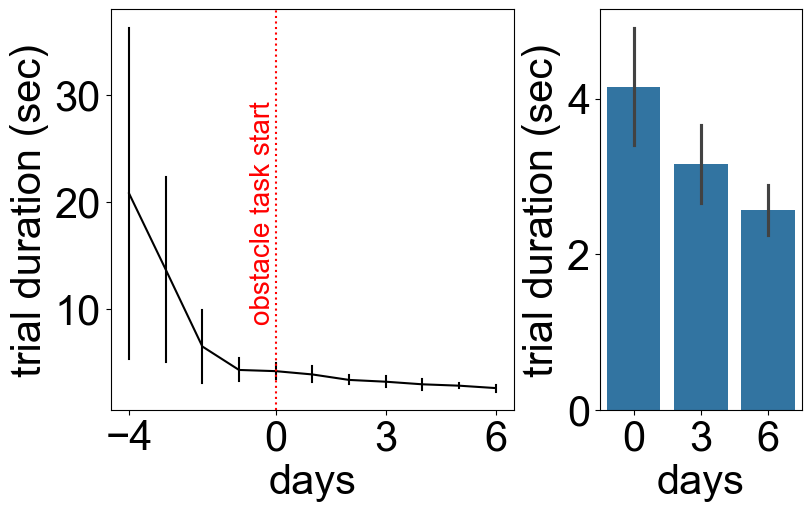

In [4]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trial duration (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel('trial duration (sec)')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trial_time' ,errorbar='sd',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
ax1.axvline(0, color='r', ls=':')
ax1.text(0, ax1.get_ylim()[1]/2,'obstacle task start', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax1.set_xticks([-4,0,3,6])
   
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trial_time',errorbar = 'sd')
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/training/trial_time.pdf',dpi = 300)

Text(0, 12.519237924828644, 'obstacle task start')

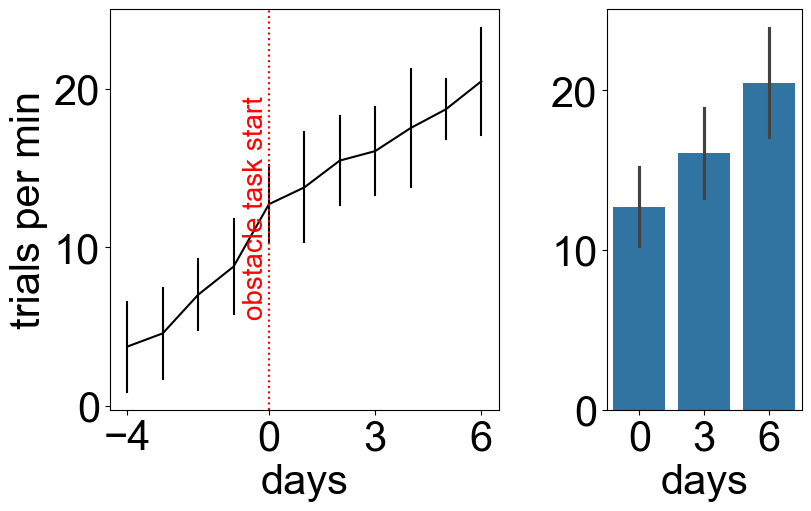

In [5]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trials per min')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trialpermin' ,errorbar='sd',err_style='bars',color = 'black')
ax1.set_xticks([-4,0,3,6])
   
bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trialpermin',errorbar = 'sd')
ax1.axvline(0, color='r', ls=':')
ax1.text(0, ax1.get_ylim()[1]/2,'obstacle task start', color='r', ha='right', va='center', rotation=90,fontsize=20)
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/training/trial_permin.eps',dpi = 300)

In [34]:
import ast

In [31]:
inds = long_short[long_short.date_index == 5].sample(2).consective_inds.tolist()

In [38]:
ast.literal_eval(ind)

[7951, 7952, 7953]

In [ ]:
data = long[long.task == 'oa']
data = data[(data.distance_at_head_turn >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
data = data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.obstacle_cluster == 5)&(data.odd == 'left')]
fig,ax = plt.subplots(layout = 'tight',figsize=(6,5))


In [49]:
trials_df.iloc[[0]]

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,turn_direction,turn_direction_end,turn_to_obstacle,obstacle_cross,head_corner_angle_velocity_at_head_turn,angle_at_head_turn,distance_traveled_at_head_turn,ts_zero_out_angle_to_target_port,consective_inds,consective_type
7813,7813,51104.814323,51109.545638,"[51104.824345, 51104.841036, 51104.857958, 511...","[[10173, 10174, 10175, 10176, 10177, 10178, 10...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[673.279296875, 674.6719360351562, 675.7409667...","[267.9906005859375, 268.22991943359375, 268.40...","[673.5612182617188, 674.7625122070312, 675.301...",...,up,down,towards,True,-6.638847,83.630208,17.663874,"[13.82013372881486, 14.9811588823302, 13.82058...","[7813, 7814, 7815]",0


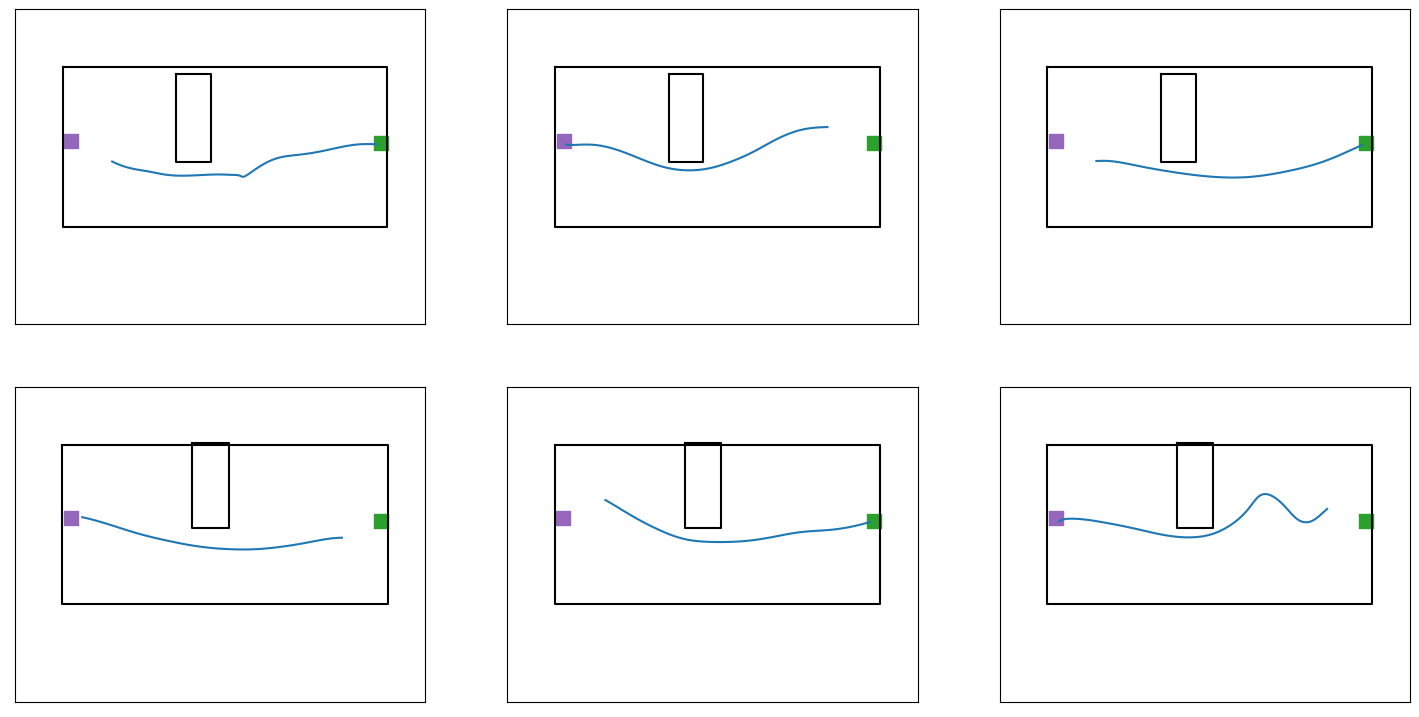

In [141]:
long_short = pd.concat([long_con_nostart,short_con_nostart])
data = long_short[long_short['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.task == 'oa')]
inds = data[data.date_index == 6].sample(2).consective_inds.tolist()
fig,axs = plt.subplots(2,3,figsize=(18,9))
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
trials_df = long_short.loc[ast.literal_eval(inds[0])][:3]
trials_df2 = long_short.loc[ast.literal_eval(inds[1])][:3]
for i in list(range(3)):
    ob_x, ob_y = plot_orginal_obstacle(trials_df,axs[0,i],trials_df.obstacle_cluster.unique()[0]) 
    plot_arena(trials_df,axs[0,i],outer=False)
    ob_x2, ob_y2 =plot_orginal_obstacle(trials_df2,axs[1,i],trials_df2.obstacle_cluster.unique()[0]) 
    plot_arena(trials_df2,axs[1,i],outer=False)
    row = trials_df.iloc[i]
    row2 = trials_df2.iloc[i]
    x, y = correct_trace(row,ob_x,ob_y)
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    axs[0,i].plot(x,y)
    axs[1,i].plot(x1,y2)


      

In [139]:
inds[0]

'[8316, 8317, 8318]'

In [130]:
inds[1]

'[8479, 8480, 8481]'

In [ ]:
'[8316, 8317, 8318]'
'[8479, 8480, 8481]'

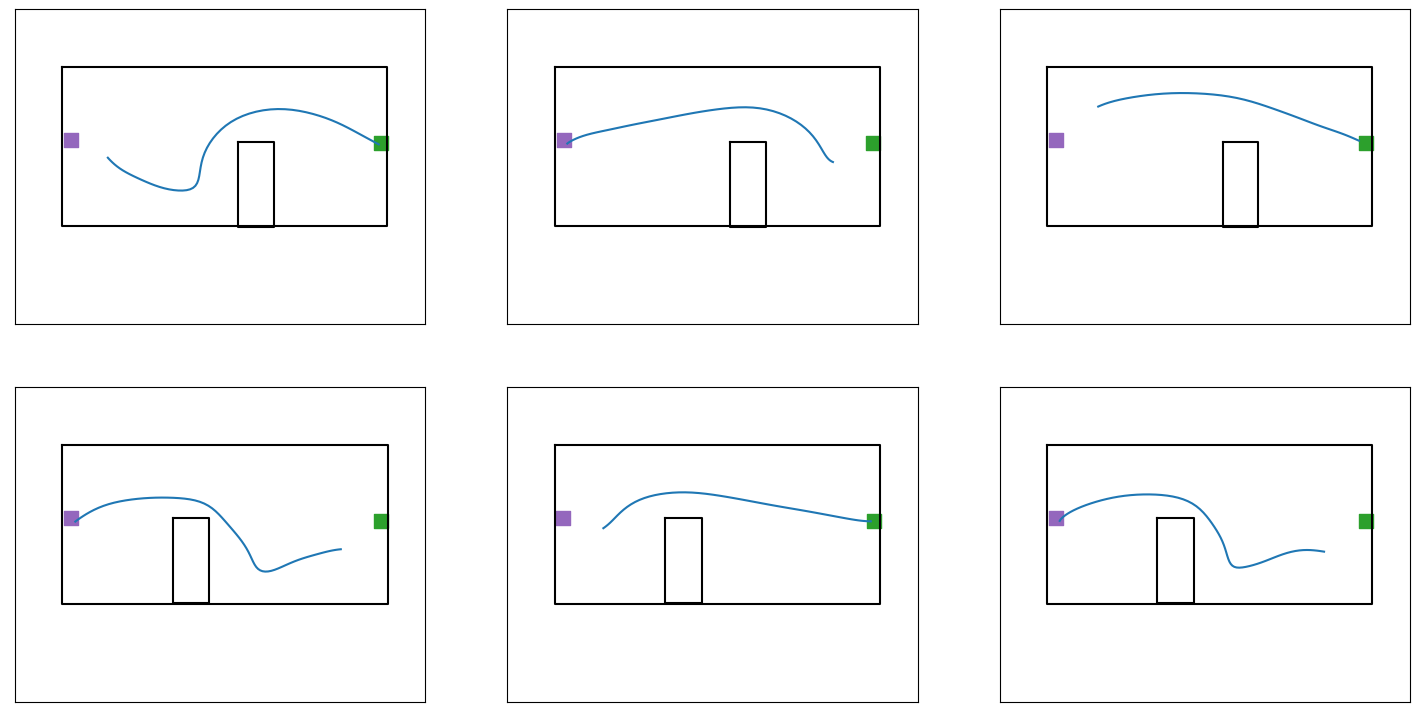

In [143]:
long_short = pd.concat([long_con_nostart,short_con_nostart])
data = long_short[long_short['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.task == 'oa')]
inds = data[data.date_index == 6].sample(2).consective_inds.tolist()
fig,axs = plt.subplots(2,3,figsize=(18,9))
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
trials_df = long_short.loc[[8316, 8317, 8318]][:3]
trials_df2 = long_short.loc[[8479, 8480, 8481]][:3]
for i in list(range(3)):
    ob_x, ob_y = plot_orginal_obstacle(trials_df,axs[0,i],trials_df.obstacle_cluster.unique()[0]) 
    plot_arena(trials_df,axs[0,i],outer=False)
    ob_x2, ob_y2 =plot_orginal_obstacle(trials_df2,axs[1,i],trials_df2.obstacle_cluster.unique()[0]) 
    plot_arena(trials_df2,axs[1,i],outer=False)
    row = trials_df.iloc[i]
    row2 = trials_df2.iloc[i]
    x, y = correct_trace(row,ob_x,ob_y)
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    axs[0,i].plot(x,y)
    axs[1,i].plot(x1,y2)
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/training/con_trials.eps',dpi = 300)
fig.savefig(r'd:\obstacle_avoidance\figures\SFN/training/con_trials.pdf',dpi = 300)


In [53]:
trials_df.obstacle_cluster.unique()[0]

5